# METALS — Feature Importance Analysis (Sreeram_experimental)

Per-asset-class cluster importance under the Jay-CSV labels.
Follows Harry's workflow: cluster MDA + MDI + SHAP, cross-method
rank agreement, within-cluster PCA + SHAP breakdown for top clusters,
global per-feature SHAP, and a pruned-vs-full CPCV(6,2) AUC
comparison.

All artifacts come from
`results/sreeram_experimental/importance/metals/` — produced
by `python -m stml.experimental.make_importance` (cluster summary)
and `python -m stml.experimental.make_importance_deep` (within-cluster
+ global SHAP + pruned-model comparison).


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

ASSET_CLASS = 'metals'
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists():
    REPO = REPO.parent
OUT = REPO / 'results' / 'sreeram_experimental' / 'importance' / ASSET_CLASS
print('Loading from:', OUT)


Loading from: /Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/metals


## 1. Cluster cross-check

Cluster ranks under each importance method, plus the
`significant` flag (MDA mean > 1 sigma above zero -> lower CI > 0).


In [2]:
crosscheck = pd.read_csv(OUT / 'cluster_crosscheck_table.csv')
crosscheck


,cluster_id,n_members,members,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,2,5,"f19_iv_rv_spread_20,f2_vol_60,f2_vol_of_vol_20...",0.008231,1,0.107750,3,0.288421,3,False
1,1,2,"f19_atm_iv_1m,f19_atm_iv_3m",0.007888,2,0.040770,12,0.091804,15,True
2,4,6,"f8_month_cos,f12_hurst_100,f9_implied_corr_z_2...",0.006454,3,0.077008,5,0.246952,4,False
3,13,3,"f19_iv_term_slope,f2_vol_ratio_20_60,f7_oi_cha...",0.004438,4,0.053236,8,0.188120,6,False
4,16,6,"f5_long_bias_20,f6_ts_momentum_60,f6_ma_cross_...",0.004412,5,0.086069,4,0.206731,5,False
5,9,2,"f12_efficiency_ratio_21,f15_path_tortuosity_20",0.004134,6,0.029471,14,0.118092,13,False
6,7,4,"f8_dow_sin,f8_dow_cos,f10_oc_ret,ewma_hmm_swit...",0.003604,7,0.026232,16,0.139359,10,True
7,15,7,"f1_bb_pctb_20,f1_rsi_14,f6_ts_momentum_20,f6_m...",0.003217,8,0.120495,2,0.326591,2,False
8,12,5,"f11_vix_rank63,f11_vix_chg20,f11_hy_oas_chg20,...",0.003170,9,0.057478,7,0.134425,11,False
9,5,5,"f5_trailing_run_length,f5_signal_entropy_20,f5...",0.002774,10,0.065548,6,0.163346,8,False


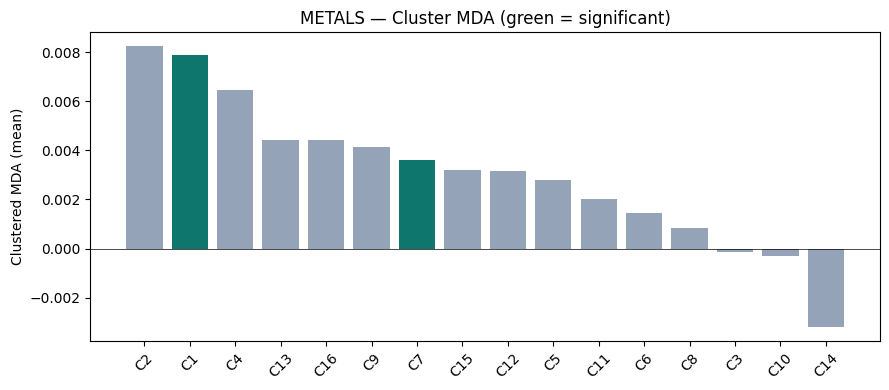

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(crosscheck))
ax.bar(x, crosscheck['mda_mean'],
       color=['#0F766E' if s else '#94a3b8' for s in crosscheck['significant']])
ax.set_xticks(x)
ax.set_xticklabels([f'C{int(c)}' for c in crosscheck['cluster_id']], rotation=45)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Clustered MDA (mean)')
ax.set_title('METALS — Cluster MDA (green = significant)')
plt.tight_layout(); plt.show()


## 2. Kendall rank agreement (MDA vs MDI vs SHAP)

Rank agreement across the three importance methods.
tau ~ 0.7+: methods agree (the typical pattern is MDI <-> SHAP).
tau < 0.4: methods disagree (typical: MDA <-> SHAP, since MDA is
the out-of-sample reality check).


In [4]:
rank_agree = pd.read_csv(OUT / 'rank_agreement.csv')
rank_agree


,metric_a,metric_b,kendall_tau,p_value
0,mdi_sum_mean,mda_mean,0.150000,0.450285
1,gain_sum_mean,mda_mean,0.150000,0.450285
2,mdi_sum_mean,gain_sum_mean,1.000000,0.000000
3,shap_sum_mean,mda_mean,0.116667,0.564267
4,shap_sum_mean,mdi_sum_mean,0.666667,0.000135


## 3. Within-cluster breakdown (top clusters by MDA)

For each top cluster: cluster members ranked by mean |SHAP|,
plus the PC1/PC2/PC3 loadings from a PCA fit on standardised
members. `pca_pc1_var_explained` >= 65% indicates a single latent
dimension (one representative suffices); 40-65% indicates a dominant
direction; < 40% indicates multi-dimensional structure.


In [5]:
import glob
wc_paths = sorted(glob.glob(str(OUT / 'within_cluster_C*.csv')))
wc_paths


['/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/metals/within_cluster_C1_f19.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/metals/within_cluster_C2_f19.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/metals/within_cluster_C3_f5.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/metals/within_cluster_C4_f12.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/metals/within_cluster_C5_f10.csv']

In [6]:
for p in wc_paths:
    name = Path(p).stem.replace('within_cluster_', '')
    df = pd.read_csv(p)
    pc1 = df['pca_pc1_var_explained'].iloc[0] * 100
    pc2 = df['pca_pc2_var_explained'].iloc[0] * 100 if 'pca_pc2_var_explained' in df.columns else 0
    print(f'--- {name}: PC1 = {pc1:.1f}%, PC1+PC2 = {pc1+pc2:.1f}%, {len(df)} members ---')
    display(df)


--- C1_f19: PC1 = 98.7%, PC1+PC2 = 100.0%, 2 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained
0,f19_atm_iv_3m,1,0.119494,0.707107,0.987187,0.707107,0.012813
1,f19_atm_iv_1m,1,0.073009,0.707107,0.987187,-0.707107,0.012813


--- C2_f19: PC1 = 58.0%, PC1+PC2 = 77.9%, 5 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f19_iv_rv_spread_20,2,0.103991,-0.370565,0.580349,0.654644,0.198622,0.422287,0.103691
1,f2_vol_60,2,0.070664,0.530681,0.580349,-0.000648,0.198622,0.151592,0.103691
2,f2_vol_of_vol_20,2,0.052031,0.458464,0.580349,-0.310895,0.198622,0.632661,0.103691
3,f9_pair_corr_mean_63,2,0.050608,0.457973,0.580349,0.296510,0.198622,-0.609894,0.103691
4,f5_flip_rate_60,2,0.019076,0.401412,0.580349,0.621987,0.198622,0.162675,0.103691


--- C3_f5: PC1 = 50.6%, PC1+PC2 = 79.9%, 5 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f5_signal_entropy_20,3,0.090118,0.271790,0.5065,0.657178,0.292592,-0.238583,0.087412
1,f5_trailing_run_length,3,0.052784,-0.295431,0.5065,-0.630558,0.292592,-0.288638,0.087412
2,f7_oi_level,3,0.050298,0.550758,0.5065,-0.186253,0.292592,0.381749,0.087412
3,f5_participation_60,3,0.020354,-0.505689,0.5065,0.185840,0.292592,0.784531,0.087412
4,ewma_hmm_prob_highvol,3,0.000000,-0.528956,0.5065,0.318256,0.292592,-0.313919,0.087412


--- C4_f12: PC1 = 44.6%, PC1+PC2 = 65.0%, 6 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f12_hurst_100,4,0.138996,-0.287631,0.446405,0.461074,0.203135,0.713527,0.13373
1,f11_eia_ng_stock_rank63,4,0.083274,-0.469112,0.446405,-0.101890,0.203135,-0.442912,0.13373
2,f9_implied_corr_z_252,4,0.046021,-0.346708,0.446405,0.523379,0.203135,-0.162803,0.13373
3,f11_move_rank63,4,0.038694,0.466944,0.446405,0.443334,0.203135,-0.004926,0.13373
4,f11_move_chg20,4,0.030679,0.357039,0.446405,0.496421,0.203135,-0.465246,0.13373
5,f8_month_cos,4,0.009792,0.481126,0.446405,-0.245203,0.203135,0.227432,0.13373


--- C5_f10: PC1 = 65.4%, PC1+PC2 = 84.4%, 4 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f10_hl_range,5,0.073494,0.374038,0.653888,0.902495,0.19024,-0.151484,0.125232
1,f2_vol_of_vol_20,5,0.070030,0.533302,0.653888,-0.210345,0.19024,0.608634,0.125232
2,f19_iv_rv_spread_20,5,0.065115,-0.479254,0.653888,0.366137,0.19024,0.761236,0.125232
3,f2_vol_20,5,0.049784,0.588218,0.653888,-0.084862,0.19024,0.164736,0.125232


## 4. Global per-feature SHAP

Mean |SHAP|, signed mean SHAP, and MDI per feature on the
asset-class modelling sample. Top features here that aren't in any
significant cluster are candidates for the pruned model.


In [7]:
gshap = pd.read_csv(OUT / 'global_shap_summary.csv')
display(gshap.head(25))


,feature,shap_magnitude,shap_signed,mdi
0,f7_overnight_gap,0.182722,-0.011930,0.015588
1,f12_hurst_100,0.138996,-0.005968,0.016387
2,f12_efficiency_ratio_21,0.134414,-0.016446,0.014605
3,f1_rsi_14,0.132524,-0.016855,0.015617
4,f19_skew_1m,0.124768,-0.006177,0.014813
5,f19_atm_iv_3m,0.119494,-0.007150,0.019412
6,f11_vix_chg5,0.111630,-0.000175,0.015260
7,f19_iv_rv_spread_20,0.103991,-0.016385,0.015560
8,f1_bb_pctb_20,0.096824,-0.003291,0.017818
9,f11_ust10_chg5,0.094457,-0.001138,0.015819


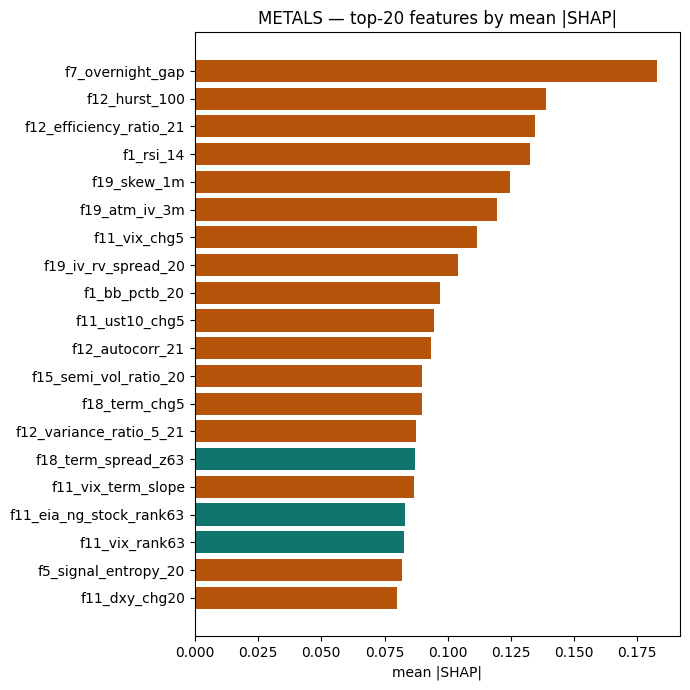

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
top = gshap.head(20).iloc[::-1]
colors = ['#0F766E' if v > 0 else '#B45309' for v in top['shap_signed']]
ax.barh(range(len(top)), top['shap_magnitude'], color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'])
ax.set_xlabel('mean |SHAP|')
ax.set_title('METALS — top-20 features by mean |SHAP|')
plt.tight_layout(); plt.show()


## 5. Pruned model — selection rule

Selection rule (per Harry / user spec):

1. For each significant cluster (MDA mean > 1 sigma):
   - PC1 >= 65% -> one representative (the top SHAP member).
   - PC1 + PC2 >= 75% -> two representatives.
   - Otherwise -> top-2 by mean |SHAP|.
2. Plus the global top-5 SHAP features not in any chosen cluster.


In [9]:
with open(OUT / 'pruned_features.json') as f:
    pruned = json.load(f)
print(f"Pruned feature set ({pruned['n_pruned']} features):")
for feat in pruned['features']:
    print(f"  - {feat:<35}  {pruned['reasons'][feat]}")


Pruned feature set (6 features):
  - f19_atm_iv_3m                        cluster 1: PC1 99% -> single rep
  - f7_overnight_gap                     global SHAP top-5
  - f12_hurst_100                        global SHAP top-5
  - f12_efficiency_ratio_21              global SHAP top-5
  - f1_rsi_14                            global SHAP top-5
  - f19_skew_1m                          global SHAP top-5


## 6. Full vs pruned model — honest held-out val AUC

Importance + global SHAP + cluster selection all computed on the
**train** partition only. Pruned features picked from train.
Both models then fit on **train** and scored on the **held-out val**
partition (never used for selection). The val AUC reported here is
an honest out-of-sample estimate of the pruning effect.


In [10]:
cmp = pd.read_csv(OUT / 'pruned_vs_full_auc.csv')
cmp


,model,n_features,n_val,val_auc,val_sem
0,full,74,380,0.529869,0.029980
1,pruned,6,380,0.528003,0.029982


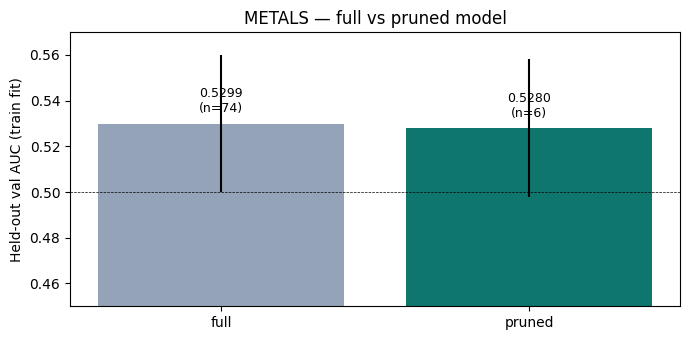

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(cmp['model'], cmp['val_auc'],
       yerr=cmp['val_sem'],
       color=['#94a3b8', '#0F766E'])
ax.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax.set_ylim(0.45, max(cmp['val_auc']) + 0.04)
for i, (m, a, n) in enumerate(zip(cmp['model'], cmp['val_auc'], cmp['n_features'])):
    ax.text(i, a + 0.005, f'{a:.4f}\n(n={int(n)})', ha='center', fontsize=9)
ax.set_ylabel('Held-out val AUC (train fit)')
ax.set_title('METALS — full vs pruned model')
plt.tight_layout(); plt.show()


## 7. Findings note (plain-text summary)

Auto-generated summary: significant clusters, top SHAP features,
the pruned feature list, and the CPCV AUC comparison.


In [12]:
print((OUT / 'findings_note.txt').read_text())


=== METALS — feature importance findings ===

Modelling sample: 1174 events; 67 features after hygiene.
Significant clusters (MDA mean > 1 sigma): 2 of 16.

Top significant clusters (by MDA):
  C1: 2 members, MDA +0.0079 +/- 0.0000, top SHAP member = f19_atm_iv_3m, PC1 var = 99%
  C7: 4 members, MDA +0.0036 +/- 0.0000, top SHAP member = ?, PC1 var = 0%

Top 10 global features by mean |SHAP|:
  f7_overnight_gap                    |SHAP| = 0.1827
  f12_hurst_100                       |SHAP| = 0.1390
  f12_efficiency_ratio_21             |SHAP| = 0.1344
  f1_rsi_14                           |SHAP| = 0.1325
  f19_skew_1m                         |SHAP| = 0.1248
  f19_atm_iv_3m                       |SHAP| = 0.1195
  f11_vix_chg5                        |SHAP| = 0.1116
  f19_iv_rv_spread_20                 |SHAP| = 0.1040
  f1_bb_pctb_20                       |SHAP| = 0.0968
  f11_ust10_chg5                      |SHAP| = 0.0945

Pruned feature set (6 features):
  - f19_atm_iv_3m  (cluster 1: 